In [ ]:
"""
EDA inicial del dataset RadioML 2016.10a
Carga el pickle, arma metadata con polars, y analiza balance por clase/SNR.
"""

import pickle
import numpy as np
import polars as pl


# -----------------------------------------------------------------
# 1. Carga del dataset
# -----------------------------------------------------------------
PATH = "RML2016.10a_dict.pkl/RML2016.10a_dict.pkl"

with open(PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

# Las claves son tuplas (modulación, SNR), ej: ('QPSK', 10)
keys = list(data.keys())
mods = sorted(set(k[0] for k in keys))
snrs = sorted(set(k[1] for k in keys))

print(f"Modulaciones encontradas ({len(mods)}): {mods}")
print(f"Niveles de SNR encontrados ({len(snrs)}): {snrs}")
print(f"Forma de cada bloque de muestras: {data[keys[0]].shape}")

# -----------------------------------------------------------------
# 2. Armar arrays numpy consolidados (X) y metadata (polars)
# -----------------------------------------------------------------
X_list = []
meta_rows = []

for (mod, snr), samples in data.items():
    n = samples.shape[0]  # normalmente 1000
    X_list.append(samples)  # shape (n, 2, 128)
    for i in range(n):
        meta_rows.append({"mod": mod, "snr": snr})

X = np.concatenate(X_list, axis=0)  # shape (N_total, 2, 128)
meta = pl.DataFrame(meta_rows)

print(f"\nDataset consolidado: X.shape = {X.shape}")
print(f"Metadata: {meta.shape[0]} filas")

# -----------------------------------------------------------------
# 3. Balance por clase y por SNR (polars)
# -----------------------------------------------------------------
print("\n--- Balance por modulación ---")
balance_mod = meta.group_by("mod").len().sort("mod")
print(balance_mod)

print("\n--- Balance por SNR ---")
balance_snr = meta.group_by("snr").len().sort("snr")
print(balance_snr)

print("\n--- Balance cruzado mod x snr (debería ser uniforme, ej. 1000 c/u) ---")
balance_cross = meta.group_by(["mod", "snr"]).len().sort(["mod", "snr"])
print(balance_cross)

# Chequeo rápido de uniformidad
counts = balance_cross["len"].to_numpy()
if counts.min() == counts.max():
    print(f"\n✅ Dataset perfectamente balanceado: {counts.min()} muestras por combinación (mod, snr).")
else:
    print(f"\n⚠️ Dataset NO balanceado. Min={counts.min()}, Max={counts.max()}")

# -----------------------------------------------------------------
# 4. Guardar metadata + array para uso posterior
# -----------------------------------------------------------------
meta.write_parquet("radioml_metadata.parquet")
np.save("radioml_X.npy", X)

print("\nGuardado: radioml_metadata.parquet, radioml_X.npy")

C:\Users\manud\AppData\Local\Temp\ipykernel_23988\1548857406.py:17: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(f, encoding="latin1")


Modulaciones encontradas (11): ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
Niveles de SNR encontrados (20): [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]
Forma de cada bloque de muestras: (1000, 2, 128)

Dataset consolidado: X.shape = (220000, 2, 128)
Metadata: 220000 filas

--- Balance por modulación ---
shape: (11, 2)
┌────────┬───────┐
│ mod    ┆ len   │
│ ---    ┆ ---   │
│ str    ┆ u32   │
╞════════╪═══════╡
│ 8PSK   ┆ 20000 │
│ AM-DSB ┆ 20000 │
│ AM-SSB ┆ 20000 │
│ BPSK   ┆ 20000 │
│ CPFSK  ┆ 20000 │
│ …      ┆ …     │
│ PAM4   ┆ 20000 │
│ QAM16  ┆ 20000 │
│ QAM64  ┆ 20000 │
│ QPSK   ┆ 20000 │
│ WBFM   ┆ 20000 │
└────────┴───────┘

--- Balance por SNR ---
shape: (20, 2)
┌─────┬───────┐
│ snr ┆ len   │
│ --- ┆ ---   │
│ i64 ┆ u32   │
╞═════╪═══════╡
│ -20 ┆ 11000 │
│ -18 ┆ 11000 │
│ -16 ┆ 11000 │
│ -14 ┆ 11000 │
│ -12 ┆ 11000 │
│ …   ┆ …     │
│ 10  ┆ 11000 │
│ 12  ┆ 11000 │
│ 14  ┆ 11000 │
│ 1

Dataset completo: X.shape = (220000, 2, 128), meta.shape = (220000, 2)

Dataset filtrado (modulaciones digitales): X_digital.shape = (160000, 2, 128)
Total de muestras: 160000 (esperado: 8 x 20 x 1000 = 160000)


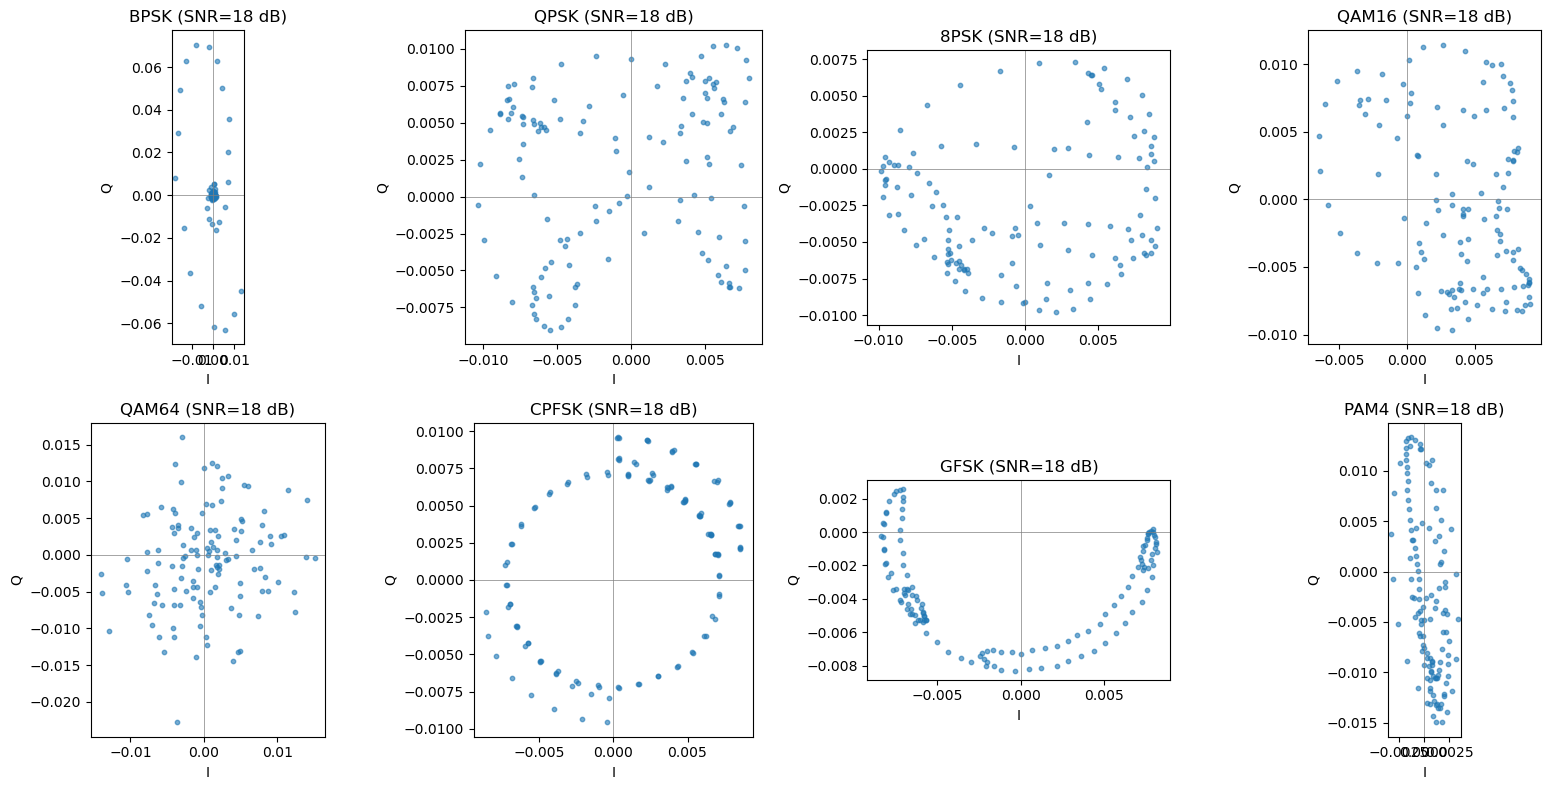


Gráfico guardado: plano_iq_por_modulacion.png


In [5]:
import matplotlib.pyplot as plt

# -----------------------------------------------------------------
# 1. Cargar lo guardado en el paso anterior
# -----------------------------------------------------------------
meta = pl.read_parquet("radioml_metadata.parquet")
X = np.load("radioml_X.npy")  # shape (220000, 2, 128)
 
print(f"Dataset completo: X.shape = {X.shape}, meta.shape = {meta.shape}")
 
# -----------------------------------------------------------------
# 2. Filtrar a modulaciones digitales (alcance del proyecto)
# -----------------------------------------------------------------
MODS_DIGITALES = ["BPSK", "QPSK", "8PSK", "QAM16", "QAM64", "CPFSK", "GFSK", "PAM4"]
 
# Agregamos un índice a meta para poder filtrar X en paralelo
meta = meta.with_row_index("orig_idx")
 
meta_digital = meta.filter(pl.col("mod").is_in(MODS_DIGITALES))
idx_digital = meta_digital["orig_idx"].to_numpy()
 
X_digital = X[idx_digital]
meta_digital = meta_digital.drop("orig_idx")
 
print(f"\nDataset filtrado (modulaciones digitales): X_digital.shape = {X_digital.shape}")
print(f"Total de muestras: {meta_digital.shape[0]} (esperado: 8 x 20 x 1000 = 160000)")
 
# Guardamos el dataset filtrado para no repetir este paso
np.save("radioml_X_digital.npy", X_digital)
meta_digital.write_parquet("radioml_metadata_digital.parquet")
 
# -----------------------------------------------------------------
# 3. Visualización en el plano IQ — una muestra por modulación a SNR alto
# -----------------------------------------------------------------
SNR_VIS = 18  # SNR alto para visualizar la constelación más "limpia"
 
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
 
for i, mod in enumerate(MODS_DIGITALES):
    # Buscamos los índices (dentro de meta_digital) que matchean mod y snr
    mask = (meta_digital["mod"] == mod) & (meta_digital["snr"] == SNR_VIS)
    indices = np.where(mask.to_numpy())[0]
 
    # Tomamos una muestra de ejemplo
    sample_idx = indices[0]
    iq = X_digital[sample_idx]  # shape (2, 128) -> [0]=I, [1]=Q
 
    axes[i].scatter(iq[0], iq[1], s=10, alpha=0.6)
    axes[i].set_title(f"{mod} (SNR={SNR_VIS} dB)")
    axes[i].set_xlabel("I")
    axes[i].set_ylabel("Q")
    axes[i].axhline(0, color="gray", linewidth=0.5)
    axes[i].axvline(0, color="gray", linewidth=0.5)
    axes[i].set_aspect("equal")
 
plt.tight_layout()
plt.savefig("plano_iq_por_modulacion.png", dpi=150)
plt.show()
 
print("\nGráfico guardado: plano_iq_por_modulacion.png")